K Nearest Neighbor classifier, from cs231n-2016-winter

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import CIFAR10

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 1

plt.rcParams['figure.figsize'] = (20.0, 16.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [3]:
def load_cifar10_numpy(root="cs231n/datasets"):
    tr = CIFAR10(root=root, train=True,  download=True)
    te = CIFAR10(root=root, train=False, download=True)

    Xtr = np.array(tr.data, dtype=np.float32)   # (50000, 32, 32, 3), uint8 -> float32
    Ytr = np.array(tr.targets, dtype=np.int64)  # (50000,)
    Xte = np.array(te.data, dtype=np.float32)   # (10000, 32, 32, 3)
    Yte = np.array(te.targets, dtype=np.int64)  # (10000,)
    return Xtr, Ytr, Xte, Yte

X_train, y_train, X_test, y_test = load_cifar10_numpy()

x_test_tiny = np.array([[2, 2, 2], [3, 4, 5]]).astype(np.float32)
x_tiny = np.array([
    [1, 1, 1], 
    [0, 0, 0], 
    [3, 3, 3], 
    [4, 4, 4], 
    [5, 5, 5]]).astype(np.float32)
y_tiny = np.array([42, 42, 42, 43, 42])

print('============================================')
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print()
print('tiny data shape: ', x_tiny.shape)
print('tiny labels shape: ', y_tiny.shape)
print('tiny test data shape: ', x_test_tiny.shape)
print()

# normalization?
# mean = np.mean(X_train, axis=0)
# std = np.std(X_train, axis=0) + 1e-8
# X_train = (X_train - mean) / std
# X_test = (X_test - mean) / std

/Users/mxz/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)

tiny data shape:  (5, 3)
tiny labels shape:  (5,)
tiny test data shape:  (2, 3)



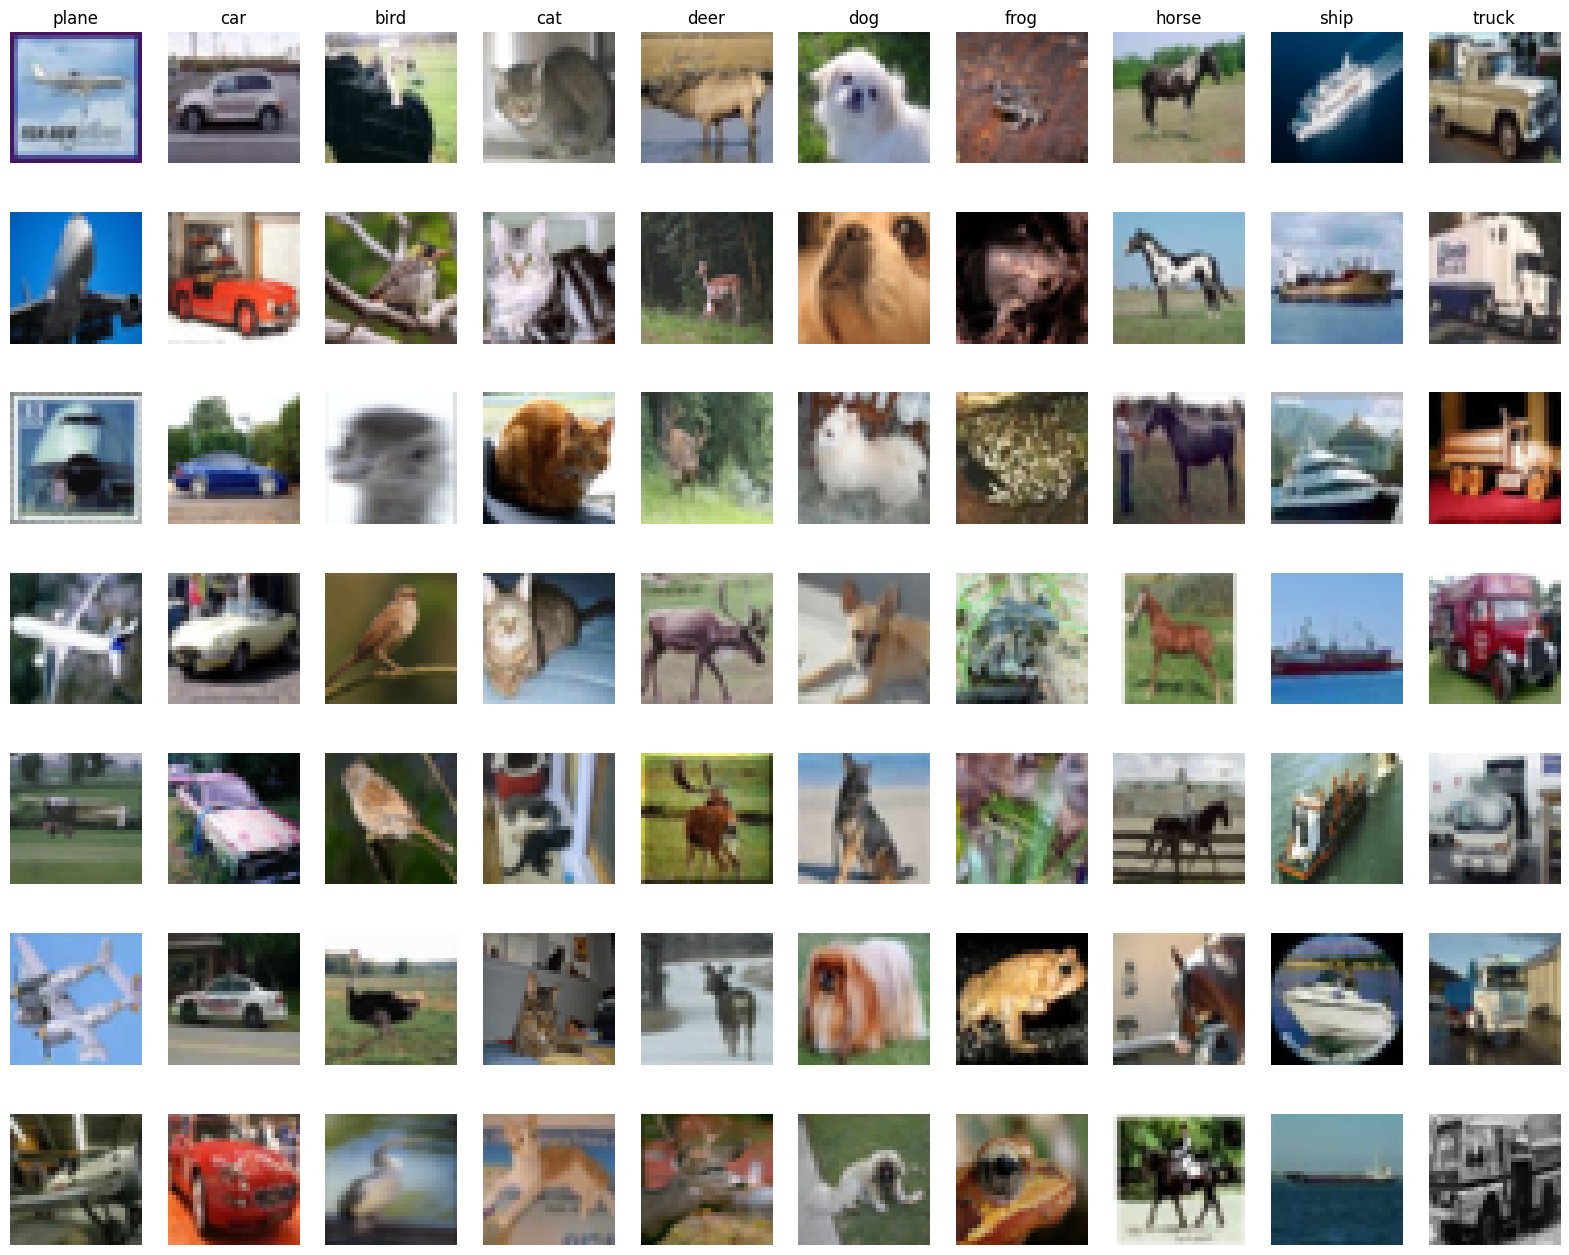

In [4]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [5]:
# Subsample the data for more efficient code execution in this exercise
num_training = 10000
mask = range(num_training)
X_train = X_train[mask].astype(np.float32)
y_train = y_train[mask]

num_test = 1000
mask = range(num_test)
X_test = X_test[mask].astype(np.float32)
y_test = y_test[mask]
# Reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

In [6]:
class KNearestNeighbor(object):
    """ a kNN classifier with L2 distance """

    def train(self, X, y):
        """
        Train the classifier. For k-nearest neighbors this is just
        memorizing the training data.

        Inputs:
        - X: A numpy array of shape (num_train, D) containing the training data
          consisting of num_train samples each of dimension D.
        - y: A numpy array of shape (N,) containing the training labels, where
             y[i] is the label for X[i].
        """
        self.X_train = X
        self.y_train = y

    def predict(self, X, k=1):
        """
        Predict labels for test data using this classifier.

        Inputs:
        - X: A numpy array of shape (num_test, D) containing test data consisting
             of num_test samples each of dimension D.
        - k: The number of nearest neighbors that vote for the predicted labels.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """

        dists = self.compute_distances_no_loops(X)
       

        return self.predict_labels(dists, k=k)



    def predict_labels(self, dists, k=1):
        """
        Given a matrix of distances between test points and training points,
        predict a label for each test point.

        Inputs:
        - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
          gives the distance betwen the ith test point and the jth training point.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """
        num_test = dists.shape[0]
        y_pred = np.zeros(num_test, dtype=int)
        for i in range(num_test):
            # A list of length k storing the labels of the k nearest neighbors to
            # the ith test point.
            # 1. check K training neighbors
            # 2. find most common label between them
            # 3. put this label into y_pred[i]

            # TODO: better naming, these are not neighbors
            train_neighbors = dists[i]
            sorted_idx = np.argsort(train_neighbors)

            k_sorted_idx = sorted_idx[:k]
            k_closest_labels = self.y_train[k_sorted_idx]
            most_popular = np.bincount(k_closest_labels).argmax()
            y_pred[i] = most_popular

        return y_pred

    def compute_distances_no_loops(self, X):
    

        X_sq = np.sum(X * X, axis=1)          # (N,)
        X_train_sq = np.sum(self.X_train * self.X_train, axis=1)          # (M,)
        cross = X @ self.X_train.T                        # (N,M)

        dists_sq = np.add.outer(X_sq, X_train_sq) - 2.0 * cross
        dists_sq = np.maximum(dists_sq, 0.0)   # guard tiny negatives
        return np.sqrt(dists_sq)

In [7]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
num_folds = 5
k_choices = [1, 6, 7, 8, 11, 12, 13]

X_train_folds = []
y_train_folds = []

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)


# A dictionary holding the accuracies for different values of k that we find
# when running cross-validation. After running cross-validation,
# k_to_accuracies[k] should be a list of length num_folds giving the different
# accuracy values that we found when using that value of k.
k_to_accuracies = {}


for k in k_choices:
    for i in range(num_folds):
        x_val = X_train_folds[i]
        y_val = y_train_folds[i]
        # concatenate all but i-th fold
        if i == 0:
            x_tr = np.concatenate(X_train_folds[1:])
            y_tr = np.concatenate(y_train_folds[1:])
        elif i == num_folds - 1:
            x_tr = np.concatenate(X_train_folds[:-1])
            y_tr = np.concatenate(y_train_folds[:-1])
        else:
            x_tr = np.concatenate(X_train_folds[:i] + X_train_folds[i+1:])
            y_tr = np.concatenate(y_train_folds[:i] + y_train_folds[i+1:])

        classifier.train(x_tr,y_tr)
        preds = classifier.predict(x_val,k)
        acc = (preds == y_val).astype(int).mean()
        if k not in k_to_accuracies:
            k_to_accuracies[k] = []
        k_to_accuracies[k].append(acc)

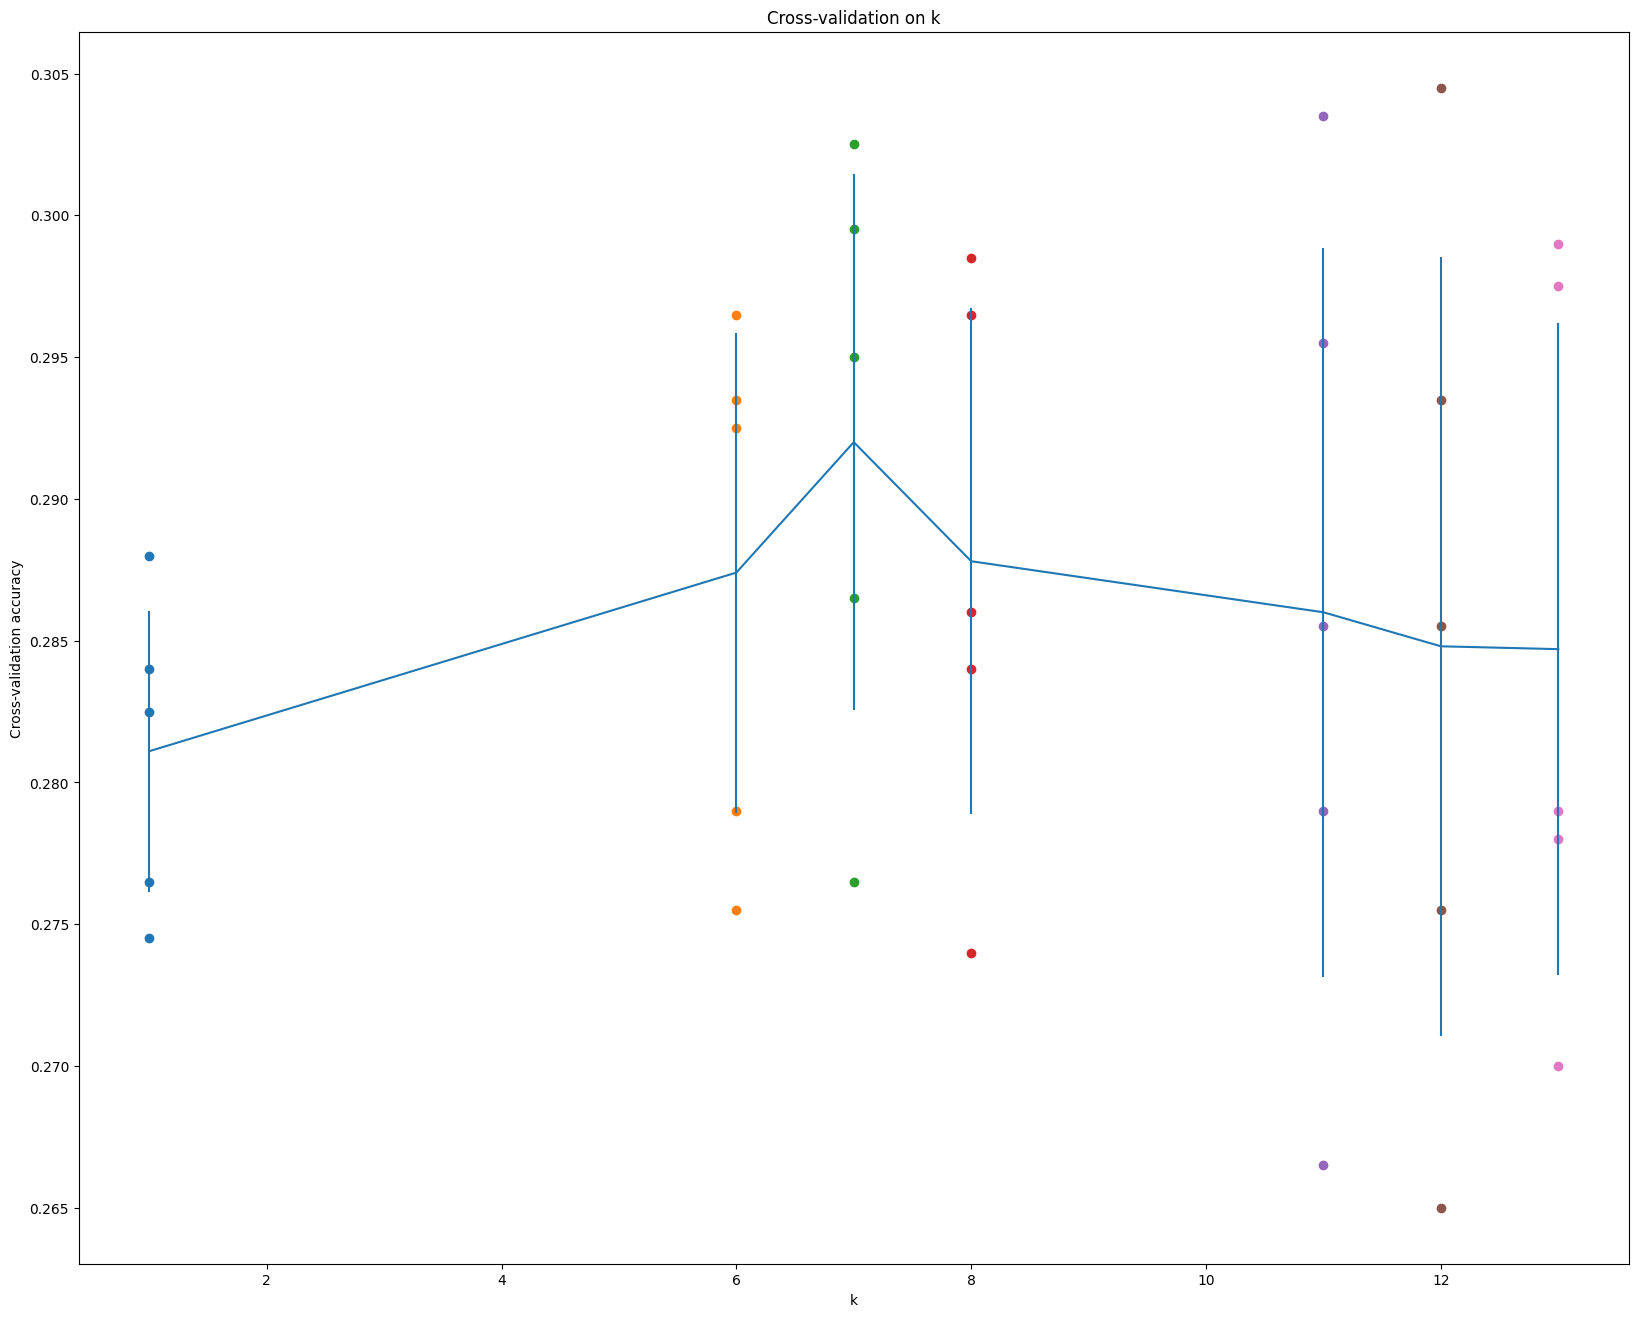

In [8]:
# plot the raw observations
for k in k_choices:
  accuracies = k_to_accuracies[k]
  plt.scatter([k] * len(accuracies), accuracies)

# plot the trend line with error bars that correspond to standard deviation
accuracies_mean = np.array([np.mean(v) for k,v in sorted(k_to_accuracies.items())])
accuracies_std = np.array([np.std(v) for k,v in sorted(k_to_accuracies.items())])
plt.errorbar(k_choices, accuracies_mean, yerr=accuracies_std)
plt.title('Cross-validation on k')
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()

In [9]:
best_k = max(k_choices, key=lambda k: np.mean(k_to_accuracies[k]))
print(f'{best_k=}')
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

# Compute and display the accuracy
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

best_k=7
Got 285 / 1000 correct => accuracy: 0.285000
